In [1]:
# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier

# EDA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Kaggle
import kagglehub


/home/orlandojunior/miniconda3/envs/kaggle/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download latest version
path = kagglehub.competition_download('playground-series-s6e5')

print("Path to competition files:", path)

Path to competition files: /home/orlandojunior/.cache/kagglehub/competitions/playground-series-s6e5


## Read the Data

In [3]:
df_train = pd.read_csv(f'{path}/train.csv')
df_test = pd.read_csv(f'{path}/test.csv')

df = pd.concat([df_train, df_test], sort=False)

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 627305 entries, 0 to 188164
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      627305 non-null  int64  
 1   Driver                  627305 non-null  str    
 2   Compound                627305 non-null  str    
 3   Race                    627305 non-null  str    
 4   Year                    627305 non-null  int64  
 5   PitStop                 627305 non-null  int64  
 6   LapNumber               627305 non-null  int64  
 7   Stint                   627305 non-null  int64  
 8   TyreLife                627305 non-null  float64
 9   Position                627305 non-null  int64  
 10  LapTime (s)             627305 non-null  float64
 11  LapTime_Delta           627305 non-null  float64
 12  Cumulative_Degradation  627305 non-null  float64
 13  RaceProgress            627305 non-null  float64
 14  Position_Change         627305 non-n

In [5]:
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## EDA

In [6]:
categorical_features = df.select_dtypes(include=['str']).columns
categorical_features

Index(['Driver', 'Compound', 'Race'], dtype='str')

In [7]:
for col in categorical_features:
    print(f'{col} - {df[col].nunique()}')

Driver - 887
Compound - 5
Race - 26


In [8]:
for col in df.select_dtypes(include=['number']).columns:
    print(f'{col} - {df[col].nunique()}')

id - 627305
Year - 4
PitStop - 2
LapNumber - 78
Stint - 8
TyreLife - 78
Position - 20
LapTime (s) - 40565
LapTime_Delta - 65243
Cumulative_Degradation - 172744
RaceProgress - 2097
Position_Change - 37
PitNextLap - 2


In [9]:
numeric_features = df.select_dtypes(include=['number']).columns
numeric_features

Index(['id', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position',
       'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
       'RaceProgress', 'Position_Change', 'PitNextLap'],
      dtype='str')

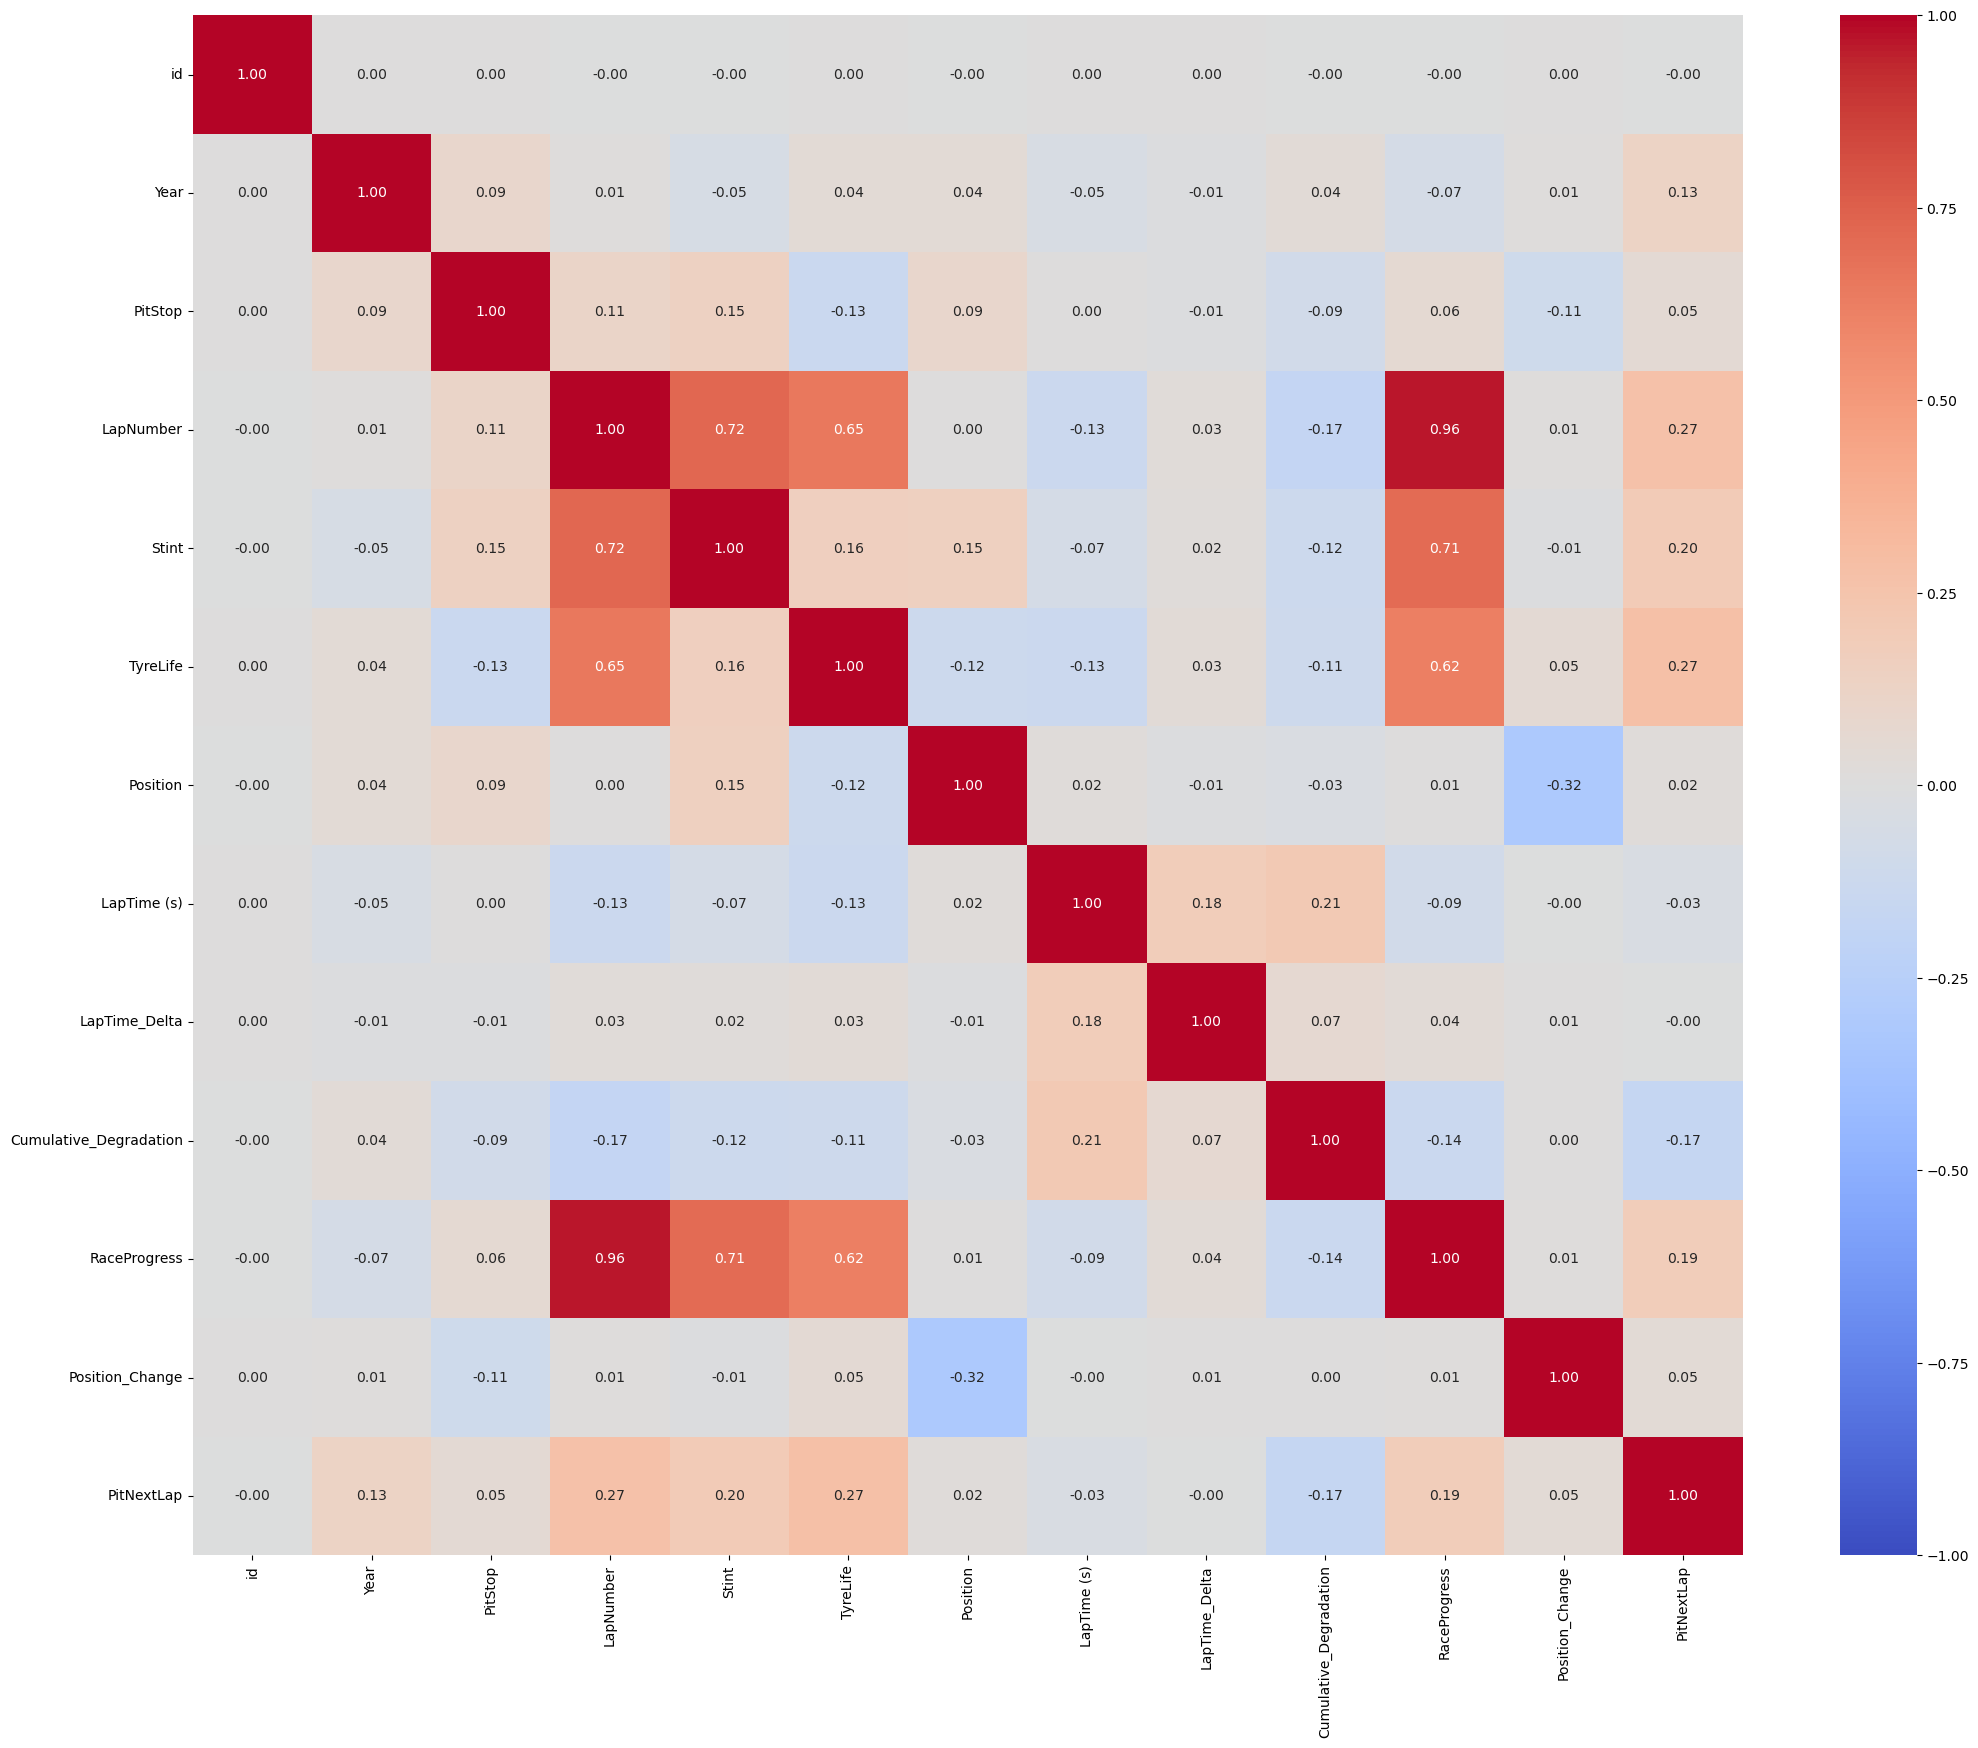

In [10]:
plt.figure(figsize=(25,20))

corr_matrix = df[numeric_features].corr()


sns.heatmap(
    corr_matrix,
    vmin=-1,
    vmax=1,
    cmap='coolwarm',
    fmt='.2f',
    annot=True
)

plt.show()

In [11]:
corr_matrix['PitNextLap'].sort_values(ascending=False)

PitNextLap                1.000000
TyreLife                  0.273510
LapNumber                 0.267057
Stint                     0.198193
RaceProgress              0.185477
Year                      0.125267
PitStop                   0.048567
Position_Change           0.046230
Position                  0.021348
id                       -0.000097
LapTime_Delta            -0.004946
LapTime (s)              -0.034096
Cumulative_Degradation   -0.167401
Name: PitNextLap, dtype: float64

In [12]:
numeric_features = df.select_dtypes(include=['number']).columns

corr_matrix = df[numeric_features].corr()
corr_matrix['PitNextLap'].sort_values(ascending=False)

PitNextLap                1.000000
TyreLife                  0.273510
LapNumber                 0.267057
Stint                     0.198193
RaceProgress              0.185477
Year                      0.125267
PitStop                   0.048567
Position_Change           0.046230
Position                  0.021348
id                       -0.000097
LapTime_Delta            -0.004946
LapTime (s)              -0.034096
Cumulative_Degradation   -0.167401
Name: PitNextLap, dtype: float64

In [13]:
df.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,439140.000000
mean,313652.000000,2023.525013,0.136162,23.089194,1.787650,14.158949,9.622600,90.960173,-3.712377,-25.760073,0.337371,0.103119,0.198982
std,181087.499645,1.025066,0.342961,16.971487,0.949778,9.816788,5.277182,20.103578,42.898465,54.812708,0.253313,4.010915,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.017000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,156826.000000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.624000,-8.879000,-46.642000,0.128571,-1.000000,0.000000
50%,313652.000000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.510000,-0.293000,-21.005000,0.269231,0.000000,0.000000
75%,470478.000000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.477000,0.118000,-6.195000,0.513158,2.000000,0.000000
max,627304.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2433.472000,2412.026000,1.000000,18.000000,1.000000


## Transforming Data

In [14]:
# Saving ids for submission
ids = df_test['id']

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 627305 entries, 0 to 188164
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      627305 non-null  int64  
 1   Driver                  627305 non-null  str    
 2   Compound                627305 non-null  str    
 3   Race                    627305 non-null  str    
 4   Year                    627305 non-null  int64  
 5   PitStop                 627305 non-null  int64  
 6   LapNumber               627305 non-null  int64  
 7   Stint                   627305 non-null  int64  
 8   TyreLife                627305 non-null  float64
 9   Position                627305 non-null  int64  
 10  LapTime (s)             627305 non-null  float64
 11  LapTime_Delta           627305 non-null  float64
 12  Cumulative_Degradation  627305 non-null  float64
 13  RaceProgress            627305 non-null  float64
 14  Position_Change         627305 non-n

In [16]:
# Removing columns

cols_to_remove = ['Driver', 'id']

df = df.drop(columns=cols_to_remove)

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 627305 entries, 0 to 188164
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Compound                627305 non-null  str    
 1   Race                    627305 non-null  str    
 2   Year                    627305 non-null  int64  
 3   PitStop                 627305 non-null  int64  
 4   LapNumber               627305 non-null  int64  
 5   Stint                   627305 non-null  int64  
 6   TyreLife                627305 non-null  float64
 7   Position                627305 non-null  int64  
 8   LapTime (s)             627305 non-null  float64
 9   LapTime_Delta           627305 non-null  float64
 10  Cumulative_Degradation  627305 non-null  float64
 11  RaceProgress            627305 non-null  float64
 12  Position_Change         627305 non-null  float64
 13  PitNextLap              439140 non-null  float64
dtypes: float64(7), int64(5), str(2)
memo

In [18]:
numerical_features = df.select_dtypes(include=['number']).columns
categorical_features = df.select_dtypes(include=['str']).columns
numerical_features = numerical_features.drop('PitNextLap')

In [19]:
df.describe()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,439140.000000
mean,2023.525013,0.136162,23.089194,1.787650,14.158949,9.622600,90.960173,-3.712377,-25.760073,0.337371,0.103119,0.198982
std,1.025066,0.342961,16.971487,0.949778,9.816788,5.277182,20.103578,42.898465,54.812708,0.253313,4.010915,0.399235
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.017000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.624000,-8.879000,-46.642000,0.128571,-1.000000,0.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.510000,-0.293000,-21.005000,0.269231,0.000000,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.477000,0.118000,-6.195000,0.513158,2.000000,0.000000
max,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2433.472000,2412.026000,1.000000,18.000000,1.000000


In [20]:
preprocessing = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),categorical_features)
    ],
    remainder='passthrough'
)

new_df_prep = preprocessing.fit_transform(df)

names = preprocessing.get_feature_names_out()

In [21]:
df = pd.DataFrame(new_df_prep,columns=names)
df.head()

,num__Year,num__PitStop,num__LapNumber,num__Stint,num__TyreLife,num__Position,num__LapTime (s),num__LapTime_Delta,num__Cumulative_Degradation,num__RaceProgress,...,cat__Race_Miami Grand Prix,cat__Race_Monaco Grand Prix,cat__Race_Pre-Season Testing,cat__Race_Qatar Grand Prix,cat__Race_Saudi Arabian Grand Prix,cat__Race_Singapore Grand Prix,cat__Race_Spanish Grand Prix,cat__Race_São Paulo Grand Prix,cat__Race_United States Grand Prix,remainder__PitNextLap
0,-1.487723,-0.397019,1.585649,0.223578,2.530468,-0.307475,-0.620247,-0.089785,0.853435,1.487942,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.438921,2.518770,0.230434,0.223578,-0.729256,-1.065456,-0.789172,-0.673792,-3.602214,0.034673,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.487723,-0.397019,2.115951,1.276457,0.798740,0.640001,-0.995603,-0.089225,-1.364081,1.903075,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.512175,-0.397019,-1.242626,-0.829300,-1.238588,-0.496970,0.169165,-0.084190,0.336347,-1.028166,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.487723,2.518770,0.171512,1.276457,-0.831123,-1.444446,0.841534,0.295521,0.212014,0.093719,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 627305 entries, 0 to 627304
Data columns (total 43 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   num__Year                            627305 non-null  float64
 1   num__PitStop                         627305 non-null  float64
 2   num__LapNumber                       627305 non-null  float64
 3   num__Stint                           627305 non-null  float64
 4   num__TyreLife                        627305 non-null  float64
 5   num__Position                        627305 non-null  float64
 6   num__LapTime (s)                     627305 non-null  float64
 7   num__LapTime_Delta                   627305 non-null  float64
 8   num__Cumulative_Degradation          627305 non-null  float64
 9   num__RaceProgress                    627305 non-null  float64
 10  num__Position_Change                 627305 non-null  float64
 11  cat__Compound_HARD      

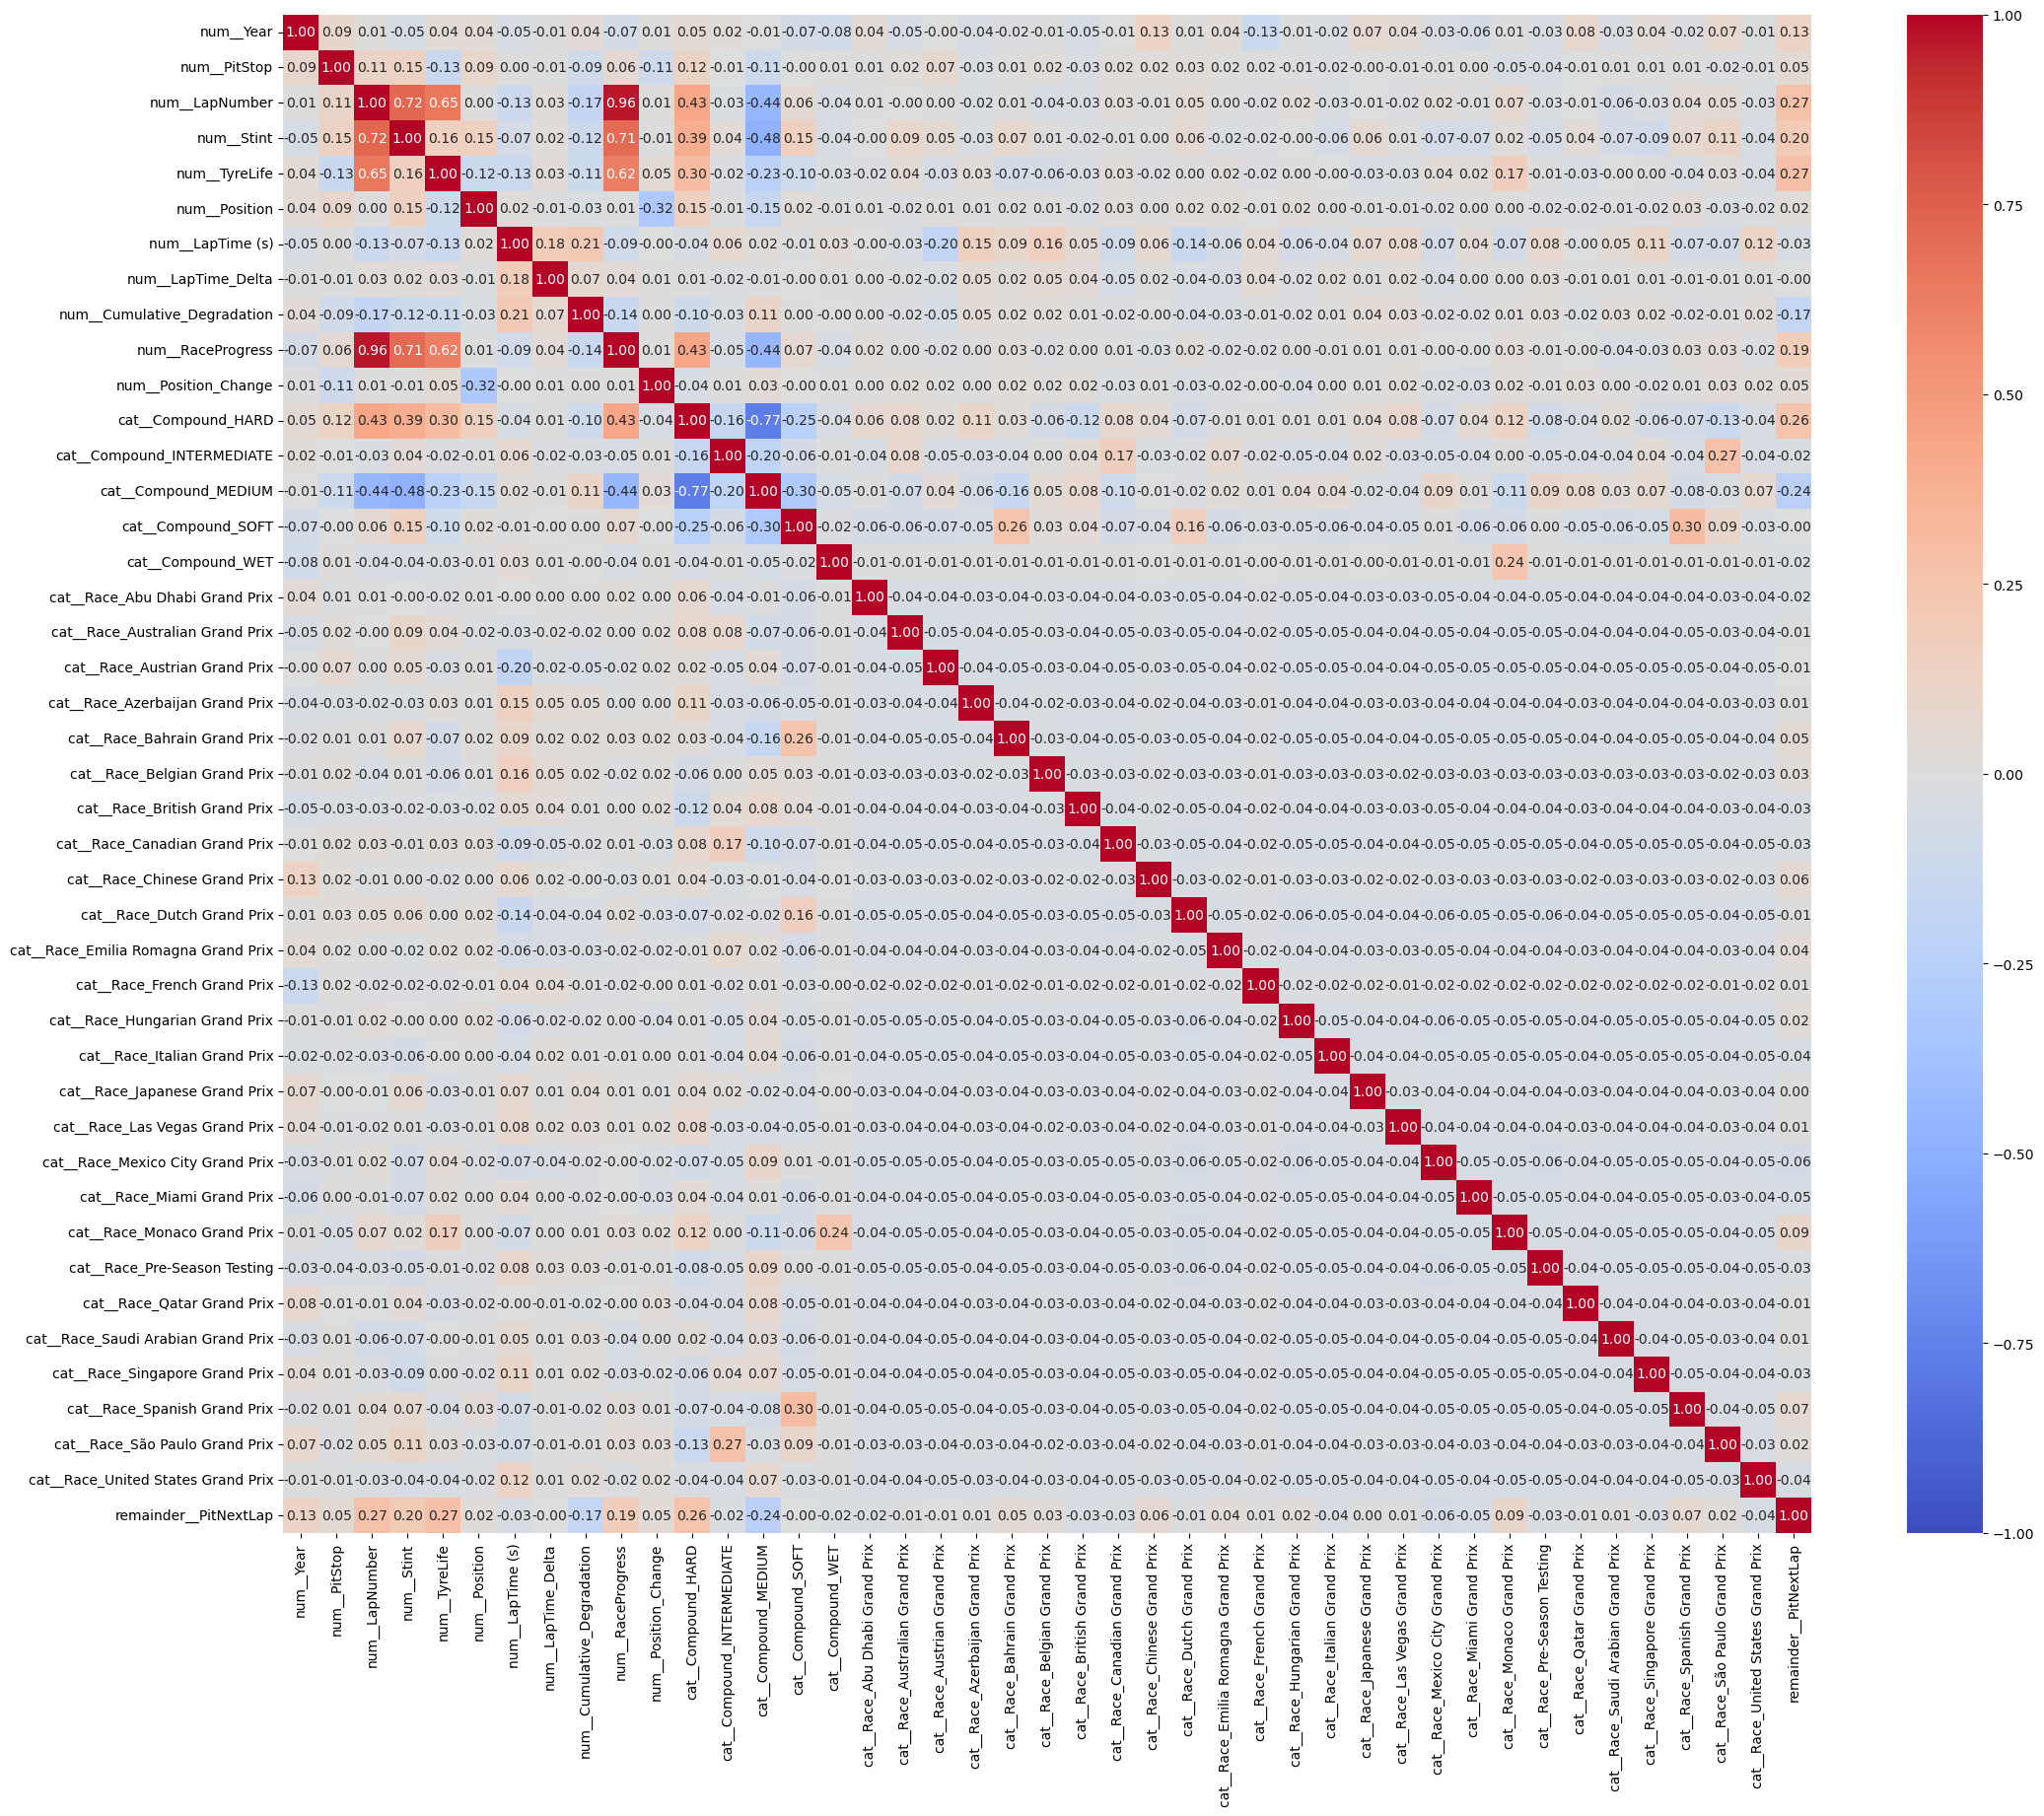

In [23]:
corr_matrix = df.corr()

plt.figure(figsize=(25,20))

sns.heatmap(
    corr_matrix,
    vmax=1,
    vmin=-1,
    fmt='.2f',
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [24]:
corr_matrix['remainder__PitNextLap'].sort_values(ascending=False)

remainder__PitNextLap                  1.000000
num__TyreLife                          0.273510
num__LapNumber                         0.267057
cat__Compound_HARD                     0.256552
num__Stint                             0.198193
num__RaceProgress                      0.185477
num__Year                              0.125267
cat__Race_Monaco Grand Prix            0.090116
cat__Race_Spanish Grand Prix           0.067033
cat__Race_Chinese Grand Prix           0.061797
num__PitStop                           0.048567
cat__Race_Bahrain Grand Prix           0.047859
num__Position_Change                   0.046230
cat__Race_Emilia Romagna Grand Prix    0.035231
cat__Race_Belgian Grand Prix           0.029496
cat__Race_Hungarian Grand Prix         0.023440
cat__Race_São Paulo Grand Prix         0.022480
num__Position                          0.021348
cat__Race_Saudi Arabian Grand Prix     0.014779
cat__Race_French Grand Prix            0.012519
cat__Race_Las Vegas Grand Prix         0

<Axes: xlabel='num__TyreLife', ylabel='num__RaceProgress'>

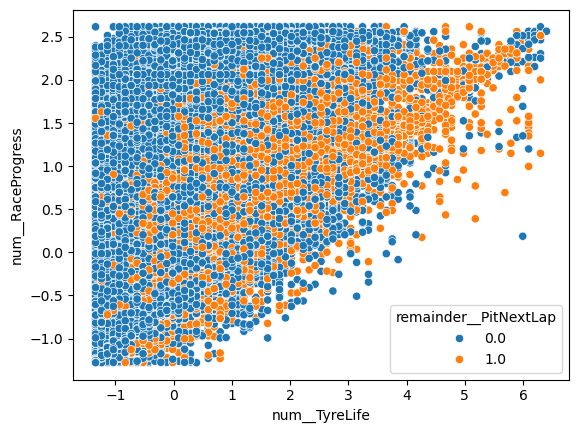

In [25]:
sns.scatterplot(df,x='num__TyreLife', y='num__RaceProgress', hue='remainder__PitNextLap')

<Axes: xlabel='num__TyreLife', ylabel='num__LapNumber'>

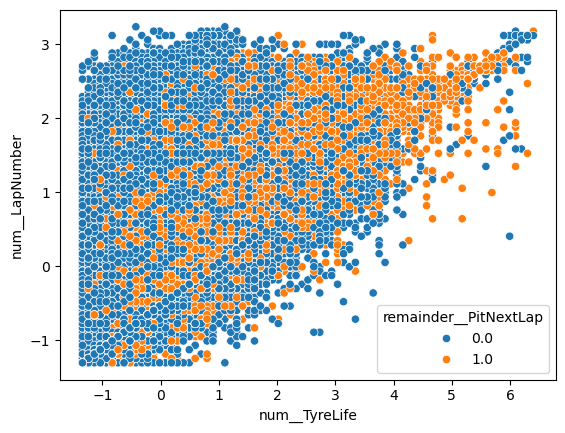

In [26]:
sns.scatterplot(df,x='num__TyreLife', y='num__LapNumber', hue='remainder__PitNextLap')

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 627305 entries, 0 to 627304
Data columns (total 43 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   num__Year                            627305 non-null  float64
 1   num__PitStop                         627305 non-null  float64
 2   num__LapNumber                       627305 non-null  float64
 3   num__Stint                           627305 non-null  float64
 4   num__TyreLife                        627305 non-null  float64
 5   num__Position                        627305 non-null  float64
 6   num__LapTime (s)                     627305 non-null  float64
 7   num__LapTime_Delta                   627305 non-null  float64
 8   num__Cumulative_Degradation          627305 non-null  float64
 9   num__RaceProgress                    627305 non-null  float64
 10  num__Position_Change                 627305 non-null  float64
 11  cat__Compound_HARD      

In [28]:
table = df.corr()['remainder__PitNextLap'].sort_values(ascending=False)
table

remainder__PitNextLap                  1.000000
num__TyreLife                          0.273510
num__LapNumber                         0.267057
cat__Compound_HARD                     0.256552
num__Stint                             0.198193
num__RaceProgress                      0.185477
num__Year                              0.125267
cat__Race_Monaco Grand Prix            0.090116
cat__Race_Spanish Grand Prix           0.067033
cat__Race_Chinese Grand Prix           0.061797
num__PitStop                           0.048567
cat__Race_Bahrain Grand Prix           0.047859
num__Position_Change                   0.046230
cat__Race_Emilia Romagna Grand Prix    0.035231
cat__Race_Belgian Grand Prix           0.029496
cat__Race_Hungarian Grand Prix         0.023440
cat__Race_São Paulo Grand Prix         0.022480
num__Position                          0.021348
cat__Race_Saudi Arabian Grand Prix     0.014779
cat__Race_French Grand Prix            0.012519
cat__Race_Las Vegas Grand Prix         0

<Axes: xlabel='cat__Compound_HARD', ylabel='num__TyreLife'>

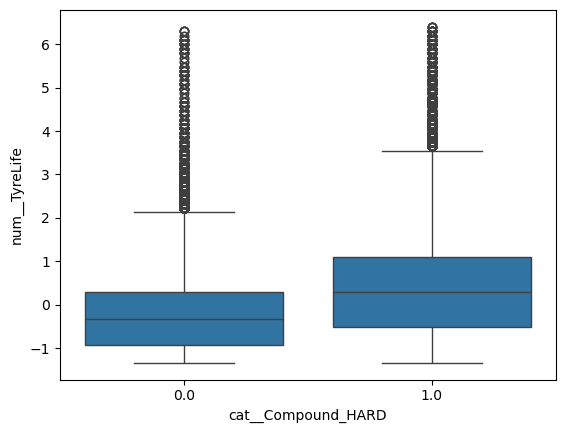

In [29]:
sns.boxplot(df,y='num__TyreLife',x='cat__Compound_HARD')

## Training the model

In [30]:
training_data = df[:df_train.shape[0]]
testing_data = df[df_train.shape[0]:]

In [31]:
training_data.shape, testing_data.shape

((439140, 43), (188165, 43))

In [32]:
training_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 43 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   num__Year                            439140 non-null  float64
 1   num__PitStop                         439140 non-null  float64
 2   num__LapNumber                       439140 non-null  float64
 3   num__Stint                           439140 non-null  float64
 4   num__TyreLife                        439140 non-null  float64
 5   num__Position                        439140 non-null  float64
 6   num__LapTime (s)                     439140 non-null  float64
 7   num__LapTime_Delta                   439140 non-null  float64
 8   num__Cumulative_Degradation          439140 non-null  float64
 9   num__RaceProgress                    439140 non-null  float64
 10  num__Position_Change                 439140 non-null  float64
 11  cat__Compound_HARD      

In [33]:
# Drop the remainder__PitNextLap on df_test

testing_data = testing_data.drop(columns='remainder__PitNextLap')

In [34]:
testing_data.head()

,num__Year,num__PitStop,num__LapNumber,num__Stint,num__TyreLife,num__Position,num__LapTime (s),num__LapTime_Delta,num__Cumulative_Degradation,num__RaceProgress,...,cat__Race_Mexico City Grand Prix,cat__Race_Miami Grand Prix,cat__Race_Monaco Grand Prix,cat__Race_Pre-Season Testing,cat__Race_Qatar Grand Prix,cat__Race_Saudi Arabian Grand Prix,cat__Race_Singapore Grand Prix,cat__Race_Spanish Grand Prix,cat__Race_São Paulo Grand Prix,cat__Race_United States Grand Prix
439140,-0.512175,-0.397019,-0.123100,-0.829300,0.696873,-1.065456,0.120716,0.093066,0.379038,0.262424,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
439141,-0.512175,-0.397019,0.053667,-0.829300,1.002472,-1.633942,-0.004635,0.083532,0.433660,0.301691,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
439142,-0.512175,-0.397019,0.053667,-0.829300,1.002472,0.261011,0.095049,0.087495,0.308653,0.490175,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
439143,0.463373,-0.397019,-1.006936,0.223578,-1.034855,1.018992,0.199309,-0.373641,0.620478,-1.024222,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
439144,0.463373,-0.397019,1.703494,0.223578,1.511804,0.450506,0.405492,0.108218,0.089616,1.519273,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [35]:
X = training_data.drop(columns='remainder__PitNextLap')
y = training_data['remainder__PitNextLap']

In [36]:
X_train, X_temp , y_train, y_temp = train_test_split(X,y, test_size=0.2, shuffle=True, stratify=y)
X_val, X_test , y_val, y_test = train_test_split(X_temp,y_temp, test_size=0.5, shuffle=True, stratify=y_temp)


X_train.shape, X_test.shape, X_val.shape

((351312, 42), (43914, 42), (43914, 42))

In [37]:
xgb = XGBClassifier(
    subsample= 1.0, 
    scale_pos_weight= 1.0,
    reg_lambda= 1.0, 
    reg_alpha= 0,
    n_estimators= 600, 
    min_child_weight=5,
    max_depth= 10,
    learning_rate = 0.05, 
    gamma = 0, 
    colsample_bytree = 0.5,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [38]:
preds = xgb.predict_proba(X_test)[:,1]
preds

array([0.00294541, 0.00041612, 0.04810605, ..., 0.00164274, 0.0081357 ,
       0.0056064 ], shape=(43914,), dtype=float32)

In [39]:
print(roc_auc_score(y_test,preds))

0.9519699988959159


In [40]:
preds_final = xgb.predict_proba(testing_data)[:,1]

df_final = pd.DataFrame({'id':ids, 'PitNextLap':preds_final})

df_final.to_csv('submission.csv',index=False)

## Melhor resultado : 0.9519699988959159